In [25]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [24]:
from pathlib import Path
import pandas as pd

# Move ONE level up from notebooks → project root
BASE_DIR = Path.cwd().parent

trips_path = BASE_DIR / "data" / "synthetic" / "trips.csv"
stops_path = BASE_DIR / "data" / "synthetic" / "stops.csv"

trips = pd.read_csv(trips_path, parse_dates=['start_time','end_time'])
stops = pd.read_csv(stops_path)

print("Trips loaded:", len(trips))


Trips loaded: 114


In [26]:
print(trips.start_time.min())
print(trips.end_time.max())


1900-01-01 06:00:00
1900-01-01 22:53:16.482116


In [27]:
trips['is_peak'].value_counts()


is_peak
False    80
True     34
Name: count, dtype: int64

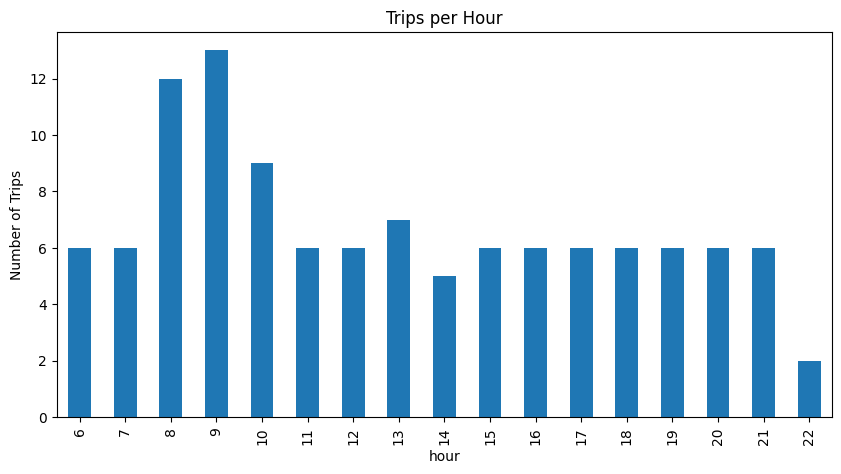

In [28]:
import matplotlib.pyplot as plt

trips['hour'] = trips.start_time.dt.hour

plt.figure(figsize=(10,5))
trips.groupby('hour').size().plot(kind='bar')
plt.title("Trips per Hour")
plt.ylabel("Number of Trips")
plt.show()


In [29]:
trips['runtime_min'] = (
    trips.end_time - trips.start_time
).dt.total_seconds()/60

print(trips.runtime_min.describe())


count    114.000000
mean      32.028483
std        5.802139
min       24.817236
25%       28.081239
50%       29.025734
75%       39.192788
max       44.167470
Name: runtime_min, dtype: float64


In [30]:
trips.direction.value_counts()


direction
0    57
1    57
Name: count, dtype: int64

In [31]:
trips[['trip_id','cycle_id','direction']].head(10)


,trip_id,cycle_id,direction
0,1,0,0
1,2,0,1
2,3,1,0
3,4,1,1
4,5,2,0
5,6,2,1
6,7,3,0
7,8,3,1
8,9,4,0
9,10,4,1


In [32]:
print(trips.energy_kwh.describe())


count    114.000000
mean      17.851716
std        0.377034
min       17.371240
25%       17.556752
50%       17.775133
75%       18.072462
max       19.200947
Name: energy_kwh, dtype: float64


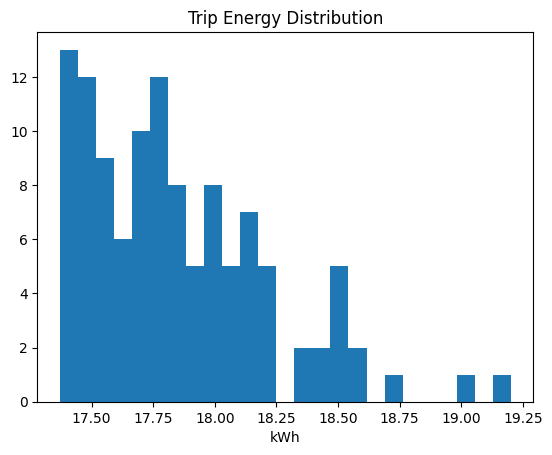

In [33]:
plt.hist(trips.energy_kwh, bins=25)
plt.title("Trip Energy Distribution")
plt.xlabel("kWh")
plt.show()


In [34]:
cycle_energy = trips.groupby('cycle_id').energy_kwh.sum()

print(cycle_energy.describe())


count    57.000000
mean     35.703432
std       0.524920
min      34.754241
25%      35.310893
50%      35.655668
75%      36.055654
max      37.356378
Name: energy_kwh, dtype: float64


<Axes: title={'center': 'Stop Positions'}>

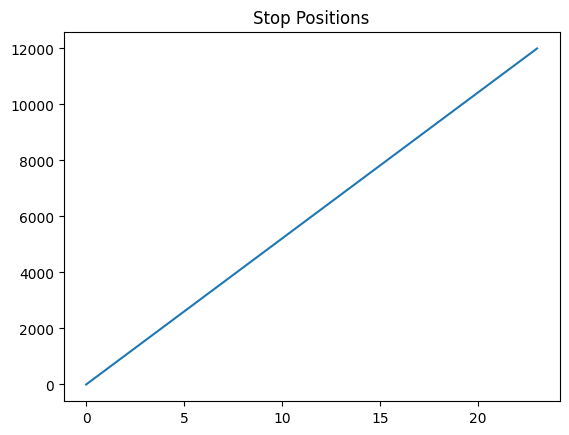

In [35]:
stops.position_m.plot(title="Stop Positions")


<Axes: title={'center': 'Elevation Profile'}>

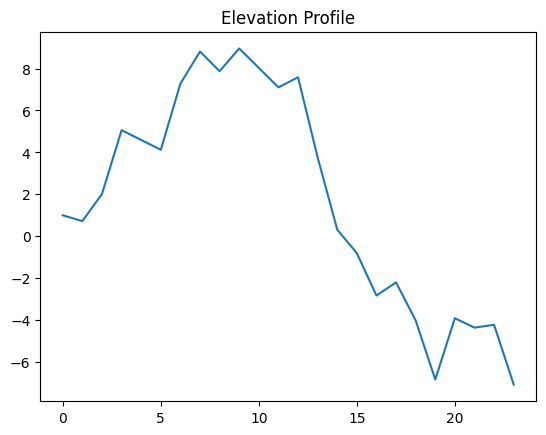

In [36]:
stops.elevation_m.plot(title="Elevation Profile")


In [40]:
BASE_DIR = Path.cwd().parent
trips.describe().to_csv(BASE_DIR / "results" / "synthetic" / "data_summary.csv")

<Axes: xlabel='hour'>

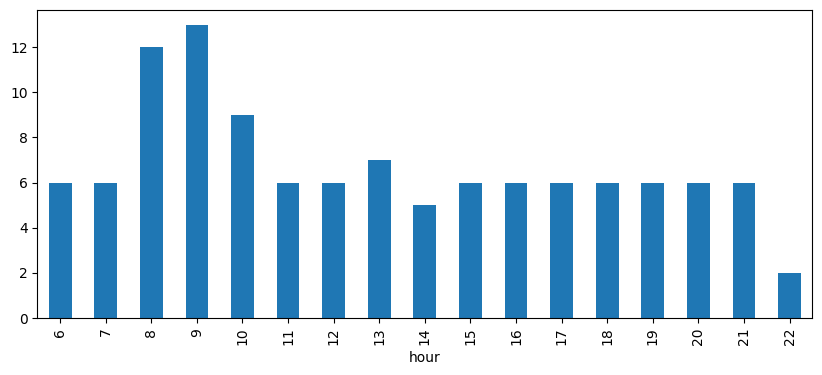

In [41]:
trips.groupby('hour').size().plot(kind='bar', figsize=(10,4))


In [42]:
trips.groupby('is_peak')['trip_id'].count()


is_peak
False    80
True     34
Name: trip_id, dtype: int64

In [43]:
trips.groupby('is_peak')['energy_kwh'].mean()


is_peak
False    17.887544
True     17.767415
Name: energy_kwh, dtype: float64

In [8]:
from pathlib import Path
import pandas as pd

# Move ONE level up from notebooks → project root
BASE_DIR = Path.cwd().parent

blocks = pd.read_csv(BASE_DIR / "results" / "synthetic" / "diesel_blocks.csv")

util = blocks.bus_id.value_counts()

print(util.describe())

count    11.000000
mean     10.363636
std       0.504525
min      10.000000
25%      10.000000
50%      10.000000
75%      11.000000
max      11.000000
Name: count, dtype: float64


In [15]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: c:\Users\abhishek chauhan\OneDrive\Desktop\Sem - 4


In [16]:
from src.baseline.diesel_baseline import diesel_fleet_sizing
from src.baseline.analytical_beb import analytical_beb_fleet


In [17]:
import pandas as pd

DATA_DIR = PROJECT_ROOT / "data" / "synthetic"

trips = pd.read_csv(
    DATA_DIR / "trips.csv",
    parse_dates=["start_time","end_time"]
)

trips.head()


,trip_id,cycle_id,direction,start_time,end_time,distance_km,num_stops,is_peak,energy_kwh
0,1,0,0,1900-01-01 06:00:00.000000,1900-01-01 06:28:58.999725,12,24,False,17.414789
1,2,0,1,1900-01-01 06:34:58.999725,1900-01-01 07:03:57.999450,12,24,False,18.106499
2,3,1,0,1900-01-01 06:18:00.000000,1900-01-01 06:46:01.610790,12,24,False,18.220177
3,4,1,1,1900-01-01 06:52:01.610790,1900-01-01 07:20:03.221580,12,24,False,17.567103
4,5,2,0,1900-01-01 06:40:00.000000,1900-01-01 07:07:53.942518,12,24,False,18.549032


In [18]:
diesel_results = diesel_fleet_sizing(trips)

diesel_results


{'N_diesel_theoretical': 8,
 'N_diesel_block': 11,
 'cycle_time_min': np.float64(70.05696555204678),
 'avg_headway_min': np.float64(9.371371603030303),
 'peak_hour': np.int32(9)}

In [19]:
beb_results = analytical_beb_fleet(
    trips,
    diesel_results,
    battery_kwh=350,
    usable_fraction=0.85
)

beb_results


{'battery_kwh': 350,
 'usable_energy_kwh': 297.5,
 'avg_cycle_energy_kwh': np.float64(35.703432043958884),
 'cycles_per_charge': np.float64(8.332532279633822),
 'total_cycles': 57,
 'N_range': 7,
 'N_BEB': 11,
 'replacement_ratio': 1.0}

In [20]:
trips.energy_kwh.describe()


count    114.000000
mean      17.851716
std        0.377034
min       17.371240
25%       17.556752
50%       17.775133
75%       18.072462
max       19.200947
Name: energy_kwh, dtype: float64

In [21]:
cycle_energy = trips.groupby("cycle_id").energy_kwh.sum()
cycle_energy.describe()


count    57.000000
mean     35.703432
std       0.524920
min      34.754241
25%      35.310893
50%      35.655668
75%      36.055654
max      37.356378
Name: energy_kwh, dtype: float64

In [22]:
350 * 0.85


297.5

In [23]:
beb_results["cycles_per_charge"]


np.float64(8.332532279633822)

In [24]:
beb_results["N_range"]
beb_results["N_BEB"]


11

In [25]:
beb_results["replacement_ratio"]


1.0

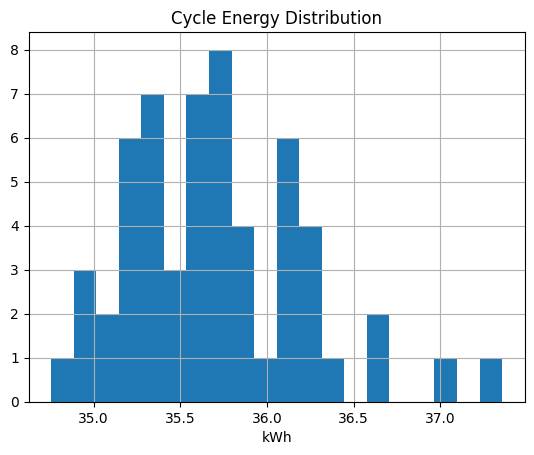

In [26]:
import matplotlib.pyplot as plt

cycle_energy.hist(bins=20)
plt.title("Cycle Energy Distribution")
plt.xlabel("kWh")
plt.show()


In [27]:
cycle_energy.describe()
beb_results


{'battery_kwh': 350,
 'usable_energy_kwh': 297.5,
 'avg_cycle_energy_kwh': np.float64(35.703432043958884),
 'cycles_per_charge': np.float64(8.332532279633822),
 'total_cycles': 57,
 'N_range': 7,
 'N_BEB': 11,
 'replacement_ratio': 1.0}

SyntaxError: invalid syntax (3244040916.py, line 6)

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [30]:
from src.baseline.analytical_beb import analytical_beb_fleet
from src.baseline.diesel_baseline import diesel_fleet_sizing


In [ ]:
from pathlib import Path
BASE_DIR = Path.cwd().parent
trips = pd.read_csv(
    BASE_DIR / "data" / "synthetic" / "trips.csv",
    parse_dates=["start_time","end_time"],
)


In [32]:
diesel_results = diesel_fleet_sizing(trips)

N_diesel = diesel_results["N_diesel_block"]
N_diesel


11

In [33]:
battery_sizes = [200,250,300,350,400,450,500]

results_list = []

for b in battery_sizes:
    
    res = analytical_beb_fleet(
        trips,
        diesel_results,
        battery_kwh=b,
        usable_fraction=0.85,
        save_outputs=False
    )
    
    results_list.append(res)

sweep_df = pd.DataFrame(results_list)

sweep_df


,battery_kwh,usable_energy_kwh,avg_cycle_energy_kwh,cycles_per_charge,total_cycles,N_range,N_BEB,replacement_ratio
0,200,170.0,35.703432,4.761447,57,12,12,1.090909
1,250,212.5,35.703432,5.951809,57,10,11,1.000000
2,300,255.0,35.703432,7.142171,57,8,11,1.000000
3,350,297.5,35.703432,8.332532,57,7,11,1.000000
4,400,340.0,35.703432,9.522894,57,6,11,1.000000
5,450,382.5,35.703432,10.713256,57,6,11,1.000000
6,500,425.0,35.703432,11.903618,57,5,11,1.000000


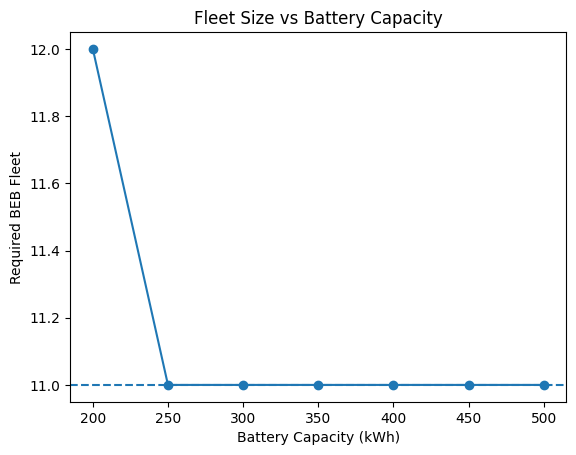

In [34]:
plt.figure()

plt.plot(
    sweep_df["battery_kwh"],
    sweep_df["N_BEB"],
    marker="o"
)

plt.axhline(
    y=N_diesel,
    linestyle="--"
)

plt.xlabel("Battery Capacity (kWh)")
plt.ylabel("Required BEB Fleet")
plt.title("Fleet Size vs Battery Capacity")

plt.show()


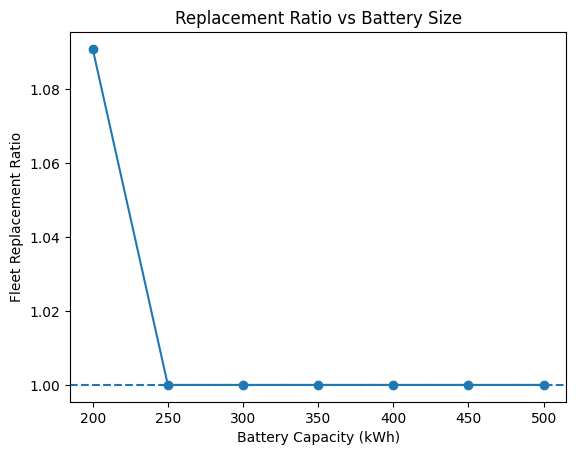

In [35]:
plt.figure()

plt.plot(
    sweep_df["battery_kwh"],
    sweep_df["replacement_ratio"],
    marker="o"
)

plt.axhline(
    y=1.0,
    linestyle="--"
)

plt.xlabel("Battery Capacity (kWh)")
plt.ylabel("Fleet Replacement Ratio")
plt.title("Replacement Ratio vs Battery Size")

plt.show()


In [36]:
sweep_df.to_csv(
    "../results/synthetic/battery_sweep.csv",
    index=False
)


In [39]:
trips.energy_kwh.describe()


count    114.000000
mean      17.851716
std        0.377034
min       17.371240
25%       17.556752
50%       17.775133
75%       18.072462
max       19.200947
Name: energy_kwh, dtype: float64

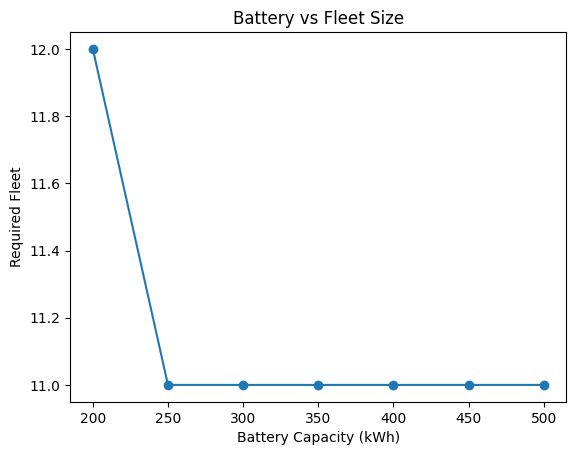

In [40]:
import matplotlib.pyplot as plt

battery = [200,250,300,350,400,450,500]
fleet = [12,11,11,11,11,11,11]

plt.plot(battery, fleet, marker='o')
plt.xlabel("Battery Capacity (kWh)")
plt.ylabel("Required Fleet")
plt.title("Battery vs Fleet Size")
plt.show()


In [41]:
from pathlib import Path

sens_dir = Path("results/sensitivity")
fig_dir = sens_dir / "figures"

sens_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.baseline.analytical_beb import analytical_beb_fleet


In [43]:
energy_mult = [0.8, 1.0, 1.2]
soc_vals = [0.75, 0.85, 0.95]
battery_vals = [250, 300, 350, 400, 450]


In [44]:
results_list = []

for e in energy_mult:
    for soc in soc_vals:
        for b in battery_vals:
            
            trips_mod = trips.copy()
            trips_mod["energy_kwh"] *= e
            
            res = analytical_beb_fleet(
                trips_mod,
                diesel_results,
                battery_kwh=b,
                usable_fraction=soc,
                save_outputs=False
            )
            
            res.update({
                "energy_mult": e,
                "usable_soc": soc,
                "battery_kwh": b
            })
            
            results_list.append(res)

sens_df = pd.DataFrame(results_list)


In [45]:
sens_df.to_csv(
    "results/sensitivity/raw_results.csv",
    index=False
)


In [46]:
summary = sens_df.groupby(
    ["energy_mult","usable_soc"]
)["replacement_ratio"].mean().reset_index()

summary.to_csv(
    "results/sensitivity/summary.csv",
    index=False
)

summary


,energy_mult,usable_soc,replacement_ratio
0,0.8,0.75,1.000000
1,0.8,0.85,1.000000
2,0.8,0.95,1.000000
3,1.0,0.75,1.000000
4,1.0,0.85,1.000000
5,1.0,0.95,1.000000
6,1.2,0.75,1.054545
7,1.2,0.85,1.018182
8,1.2,0.95,1.000000


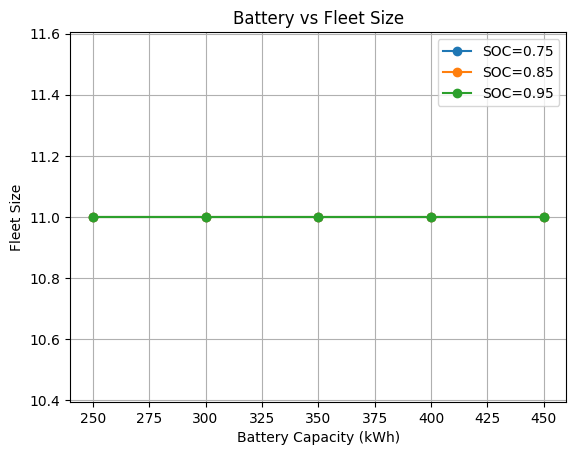

In [47]:
for soc in soc_vals:
    subset = sens_df[
        (sens_df.usable_soc == soc) &
        (sens_df.energy_mult == 1.0)
    ]
    
    plt.plot(
        subset.battery_kwh,
        subset.N_BEB,
        marker="o",
        label=f"SOC={soc}"
    )

plt.xlabel("Battery Capacity (kWh)")
plt.ylabel("Fleet Size")
plt.title("Battery vs Fleet Size")
plt.legend()
plt.grid()

plt.savefig("results/sensitivity/figures/battery_vs_fleet.png", dpi=300)
plt.show()


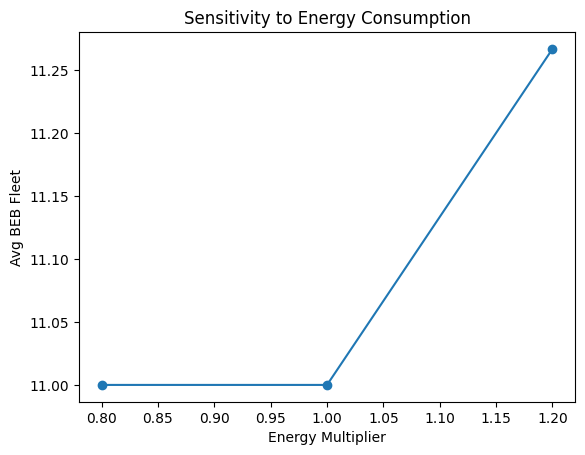

In [48]:
avg = sens_df.groupby("energy_mult")["N_BEB"].mean()

avg.plot(marker="o")

plt.xlabel("Energy Multiplier")
plt.ylabel("Avg BEB Fleet")
plt.title("Sensitivity to Energy Consumption")

plt.savefig("results/sensitivity/figures/energy_sensitivity.png", dpi=300)
plt.show()


In [49]:
with open("results/sensitivity/experiment_log.txt","w") as f:
    f.write("Advanced Sensitivity Study\n")
    f.write("-------------------------\n")
    f.write(f"Energy multipliers: {energy_mult}\n")
    f.write(f"SOC values: {soc_vals}\n")
    f.write(f"Battery values: {battery_vals}\n")
    f.write(f"Diesel fleet baseline: {diesel_results['N_diesel_block']}\n")


In [50]:
from src.optimization.beb_soc_scheduler import beb_soc_scheduler

res = beb_soc_scheduler(
    trips,
    battery_kwh=350
)

print("BEB fleet with SOC:", res["N_BEB_SOC"])


BEB fleet with SOC: 11


In [51]:
res["assignments"].soc_after.min()


np.float64(0.17754483436389937)

<Axes: >

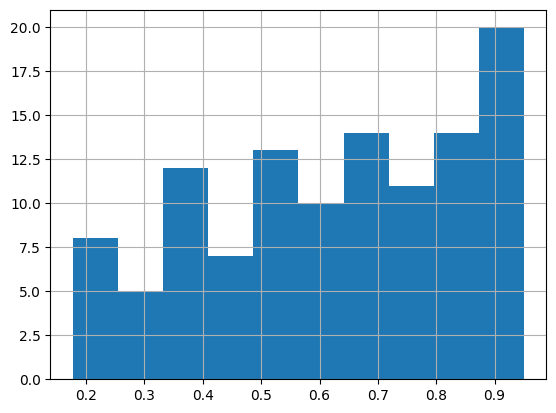

In [52]:
res["assignments"].soc_after.hist()


In [54]:
res["assignments"].soc_after.min()


np.float64(0.17754483436389937)

In [55]:
print(res["N_BEB_SOC"])


11


In [56]:
for b in [300,250,200]:
    res = beb_soc_scheduler(trips, battery_kwh=b)
    print(b, res["N_BEB_SOC"])


300 11
250 12
200 14


In [5]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))


In [9]:
from src.optimization.mip_scheduler import solve_beb_mip
fleet = solve_beb_mip(trips.iloc[:30])
print(fleet)


NameError: name 'trips' is not defined

In [10]:
fleet = solve_beb_mip(trips.iloc[:30])
print(fleet)


NameError: name 'trips' is not defined

In [7]:
fleet_mip = solve_beb_mip(trips)

print("Optimized BEB fleet:", fleet_mip)

NameError: name 'trips' is not defined

In [11]:
!pip install pyomo highspy


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\ProgramData\Miniconda3\python.exe -m pip install --upgrade pip


In [12]:
def solve_beb_mip(trips_df, battery_kwh=350, soc_min=0.15):

    df = trips_df.copy().reset_index(drop=True)
    n = len(df)

    usable_energy = battery_kwh * (1 - soc_min)

    model = pyo.ConcreteModel()
    model.T = range(n)

    # -------- Feasible connections --------
    feasible = []
    for i in model.T:
        for j in model.T:
            if i == j:
                continue
            if df.start_time[j] >= df.end_time[i]:
                if df.energy_kwh[i] + df.energy_kwh[j] <= usable_energy:
                    feasible.append((i,j))

    model.A = pyo.Set(initialize=feasible)

    model.x = pyo.Var(model.A, domain=pyo.Binary)
    model.y = pyo.Var(model.T, domain=pyo.Binary)

    # -------- Each trip has one predecessor or start --------
    def one_pred_rule(m,j):
        return sum(m.x[i,j] for (i,j2) in m.A if j2==j) + m.y[j] == 1
    model.one_pred = pyo.Constraint(model.T, rule=one_pred_rule)

    # -------- Each trip has at most one successor --------
    def one_succ_rule(m,i):
        return sum(m.x[i,j] for (i2,j) in m.A if i2==i) <= 1
    model.one_succ = pyo.Constraint(model.T, rule=one_succ_rule)

    # -------- Objective --------
    model.obj = pyo.Objective(
        expr=sum(model.y[i] for i in model.T),
        sense=pyo.minimize
    )

    solver = pyo.SolverFactory("highs")
    solver.solve(model)

    fleet = sum(pyo.value(model.y[i]) for i in model.T)

    return int(fleet)

In [14]:
import pandas as pd
from pathlib import Path

# Use project root so notebook runs regardless of working directory
BASE_DIR = Path.cwd().parent
trips = pd.read_csv(
    BASE_DIR / "data" / "synthetic" / "trips.csv",
    parse_dates=["start_time","end_time"],
)

trips.head()


,trip_id,cycle_id,direction,start_time,end_time,distance_km,num_stops,is_peak,energy_kwh
0,1,0,0,1900-01-01 06:00:00.000000,1900-01-01 06:28:58.999725,12,24,False,17.414789
1,2,0,1,1900-01-01 06:34:58.999725,1900-01-01 07:03:57.999450,12,24,False,18.106499
2,3,1,0,1900-01-01 06:18:00.000000,1900-01-01 06:46:01.610790,12,24,False,18.220177
3,4,1,1,1900-01-01 06:52:01.610790,1900-01-01 07:20:03.221580,12,24,False,17.567103
4,5,2,0,1900-01-01 06:40:00.000000,1900-01-01 07:07:53.942518,12,24,False,18.549032


In [23]:
import pyomo.environ as pyo


In [25]:
fleet = solve_beb_mip(trips.iloc[:25])
print(fleet)


ERROR: Rule failed when generating expression for Constraint one_succ with
index 15: ValueError: Invalid constraint expression. The constraint expression
resolved to a trivial Boolean (True) instead of a Pyomo object. Please modify
your rule to return Constraint.Feasible instead of True.

    Error thrown for Constraint 'one_succ[15]'
ERROR: Constructing component 'one_succ' from data=None failed:
        ValueError: Invalid constraint expression. The constraint expression
        resolved to a trivial Boolean (True) instead of a Pyomo object. Please
        modify your rule to return Constraint.Feasible instead of True.

    Error thrown for Constraint 'one_succ[15]'


ValueError: Invalid constraint expression. The constraint expression resolved to a trivial Boolean (True) instead of a Pyomo object. Please modify your rule to return Constraint.Feasible instead of True.

Error thrown for Constraint 'one_succ[15]'

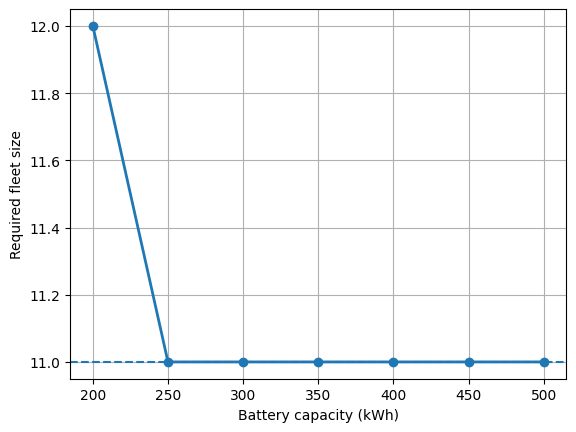

In [1]:
import matplotlib.pyplot as plt

battery = [200,250,300,350,400,450,500]
fleet = [12,11,11,11,11,11,11]

plt.figure()

plt.plot(battery, fleet, marker='o', linewidth=2)

# Diesel reference line
plt.axhline(11, linestyle='--')

plt.xlabel("Battery capacity (kWh)")
plt.ylabel("Required fleet size")

plt.grid(True)

plt.savefig("battery_vs_fleet.png", dpi=300, bbox_inches='tight')
plt.show()


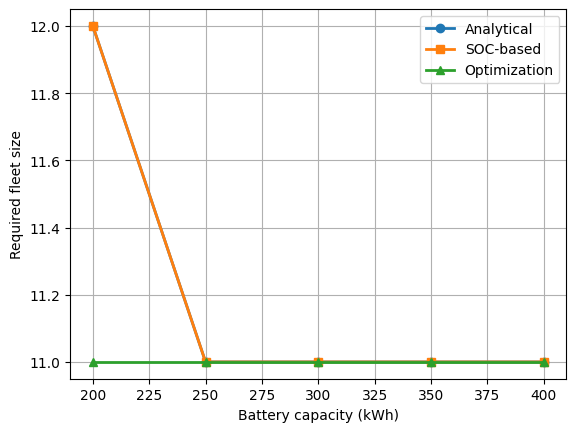

In [2]:
import matplotlib.pyplot as plt

battery = [200,250,300,350,400]

analytical = [12,11,11,11,11]
soc = [12,11,11,11,11]
mip = [11,11,11,11,11]

plt.figure()

plt.plot(battery, analytical, marker='o', linewidth=2, label="Analytical")
plt.plot(battery, soc, marker='s', linewidth=2, label="SOC-based")
plt.plot(battery, mip, marker='^', linewidth=2, label="Optimization")

plt.xlabel("Battery capacity (kWh)")
plt.ylabel("Required fleet size")

plt.legend()
plt.grid(True)

plt.savefig("method_comparison.png", dpi=300, bbox_inches='tight')
plt.show()


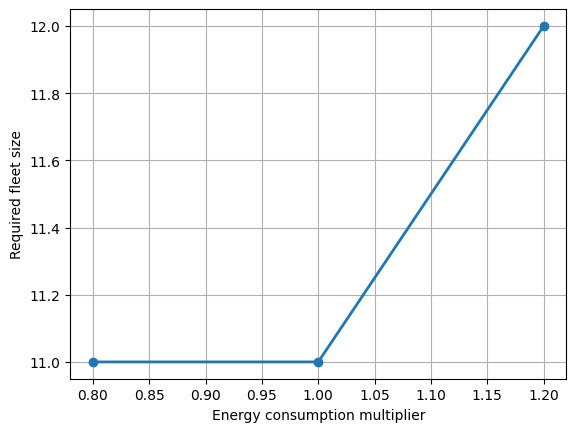

In [3]:
import matplotlib.pyplot as plt

energy_mult = [0.8, 1.0, 1.2]
fleet = [11, 11, 12]  # adjust if your exact results differ

plt.figure()

plt.plot(energy_mult, fleet, marker='o', linewidth=2)

plt.xlabel("Energy consumption multiplier")
plt.ylabel("Required fleet size")

plt.grid(True)

plt.savefig("energy_sensitivity.png", dpi=300, bbox_inches='tight')
plt.show()


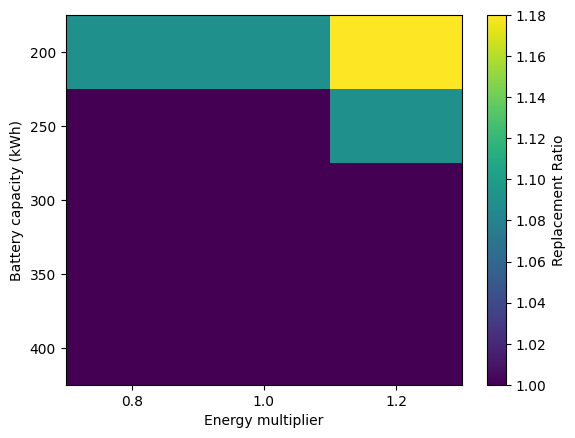

In [4]:
import matplotlib.pyplot as plt
import numpy as np

battery = [200,250,300,350,400]
energy = [0.8,1.0,1.2]

R = np.array([
    [1.09,1.09,1.18],
    [1.00,1.00,1.09],
    [1.00,1.00,1.00],
    [1.00,1.00,1.00],
    [1.00,1.00,1.00],
])

plt.figure()

plt.imshow(R, aspect='auto')
plt.colorbar(label="Replacement Ratio")

plt.xticks(range(len(energy)), energy)
plt.yticks(range(len(battery)), battery)

plt.xlabel("Energy multiplier")
plt.ylabel("Battery capacity (kWh)")

plt.savefig("heatmap.png", dpi=300, bbox_inches='tight')
plt.show()
